# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**

**Dr Luis Eduardo Falcón Morales**

**Tecnológico de Monterrey**
### **Actividad Individual: Pronósticos con Series de Tiempo**


#### **Nombre:** CRISTIAN JUAN CARLOS PAZ CONDE
#### **Matrícula:** A01840610

Modelos para predicción de un problema de serie de tiempo:

* **1. Modelo ingenuo**
* **2. Modelo ARIMA**
* **3. Modelo Prophet**
* **4. Modelo LSTM**


NOTA: Recuerda que cada modelo puede llegar a tener una gran cantidad de hiperparámetros y tipo de ajsutes, por lo que siempre inicia con un modelo sencillo y de ahí buscar mejorar su resultado. Esto para no desgastarte desde un inicio buscando la mayor cantidad de ajustes e hiperparámetros.

# **A - Introducción**

In [32]:
# Agrega aquí todas las librerías y paquetes adicionales que requieras.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# **Ejercicio 1**

* **1a. De la página de Google-Trends generar y descargar los datos con períodos mensuales que se obtienen con el "Término de búsqueda" de "chocolate", del país "Estados Unidos", de los últimos 20 años (del 1 de mayo del 2006 al 30 de abril del 2026) y con las opciones de "todas las categorías" y "búsqueda de web". De manera predeterminada se generan datos mensuales.**

* **1b. Cargar los datos en un DataFrame de Pandas llamado "dfp" y con los nombres"ds" y "y" para las columnas de fechas y porcentajes de interés de búsqueda, respectivamente. Las fechas ajustarlas al formato YYYY-MM-DD, con días de fin de mes. Este formato es el que se requiere para el modelo Prophet.**

* **1c. A partir del DataFrame "dfp", genera ahora el DataFrame que llamaremos "dfr" para el resto de los modelos. El formato en "dfr" requerido para el resto de los modelos debe tener la primera columna de fechas de "dfp" ahora como índice del DataFrame "dfr". Además, el índice de fechas debe tener una frecuencia mensual al final del mes.**



https://trends.google.es/trends/



In [6]:
# Ejercicios 1a y 1b.

# ************* Inlcuye aquí tu código:*****************************


# Leer archivo descargado desde Google Trends
dfp = pd.read_csv("data/data_chocolate.csv", skiprows=2)

# Renombrar columnas
dfp.columns = ["ds", "y"]

# Convertir fechas al formato requerido por Prophet
dfp["ds"] = pd.to_datetime(dfp["ds"]) + pd.offsets.MonthEnd(0)

# Asegurar que y sea numérica
dfp["y"] = pd.to_numeric(dfp["y"])

# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por el modelo Prophet de Meta:")
print("Dimensión del DataFrame:", dfp.shape)
print(dfp.head())
print(dfp.tail())


Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por el modelo Prophet de Meta:
Dimensión del DataFrame: (244, 2)
          ds   y
0 2006-01-31  31
1 2006-02-28  40
2 2006-03-31  25
3 2006-04-30  26
4 2006-05-31  24
            ds    y
239 2025-12-31  100
240 2026-01-31   74
241 2026-02-28   80
242 2026-03-31   63
243 2026-04-30   60


In [4]:
print(dfp["ds"].duplicated().sum())

112


In [7]:
len(dfp)

244

In [8]:
# Ejercicio 1c.

# ************* Inlcuye aquí tu código:*****************************


dfr = dfp.copy()

dfr.set_index("ds", inplace=True)

# Eliminar duplicados si existen
dfr = dfr[~dfr.index.duplicated(keep='first')]

# Frecuencia mensual fin de mes
dfr = dfr.asfreq("ME")

# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por los modelos restantes:")
print(dfr.shape)
print(dfr.head())
print(dfr.index)


Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por los modelos restantes:
(244, 1)
             y
ds            
2006-01-31  31
2006-02-28  40
2006-03-31  25
2006-04-30  26
2006-05-31  24
DatetimeIndex(['2006-01-31', '2006-02-28', '2006-03-31', '2006-04-30',
               '2006-05-31', '2006-06-30', '2006-07-31', '2006-08-31',
               '2006-09-30', '2006-10-31',
               ...
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31', '2026-01-31', '2026-02-28',
               '2026-03-31', '2026-04-30'],
              dtype='datetime64[us]', name='ds', length=244, freq='ME')


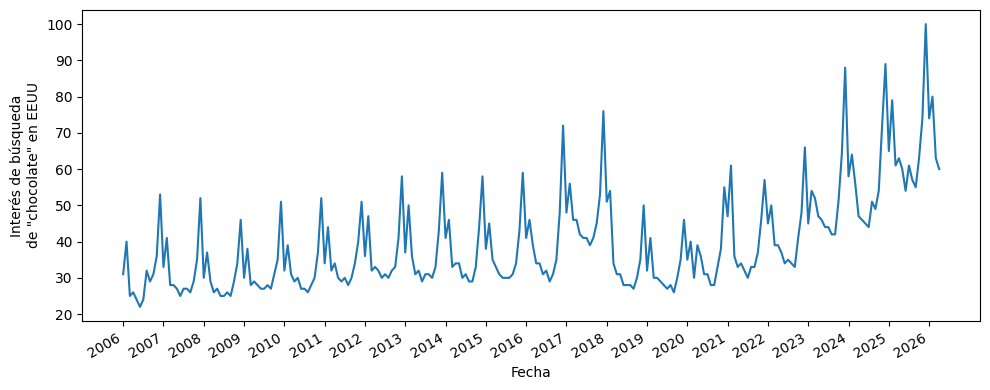

In [10]:
# Veamos el comportamiento de la serie de tiempo, en particular usemos dfp:

plt.rcParams['figure.figsize'] = (10,4)
fig, ax = plt.subplots()
ax.plot(dfp['y'])
ax.set_xlabel('Fecha')
ax.set_ylabel('Interés de búsqueda\nde \"chocolate\" en EEUU')

xticks_locs = np.arange(0, len(dfp), 12)
xticks_labels = np.arange(2006, 2027, 1)
plt.xticks(xticks_locs, xticks_labels)

fig.autofmt_xdate()
plt.tight_layout()

In [11]:
# Partición:
# Particionamos en conjunto de Prueba, Validación y Prueba de acuerdo a
# datos de una serie de tiempo y considerando el caso Prophet y el resto
# de los modelos.
# Hacemos esta diferenciación solo por fines prácticos de la actividad y
# en su momento utilizar los conjuntos respectivos en cada caso de manera
# más sencilla en la actividad.

# Para el modelo Prophet:
testP = dfp[-12:]      # El último año para prueba.
valP = dfp[-24:-12]    # El penúltimo año para validación.
trainP = dfp[:-24]     # El resto de los primeros datos para entrenamiento.

# Para el resto de los modelos:
testR = dfr[-12:]
valR = dfr[-24:-12]
trainR = dfr[:-24]


* **El objetivo de esta actividad es encontrar un modelo que pueda predecir el interés de búsqueda de la palabra "chocolate" en el navegador de Google para el próximo año. Para ello, buscaremos el modelo entrenando y validando con los conjuntos Train y Val, midiendo el desempeño con el error MAE. Con el mejor modelo encontrado obtendremos el desempeño final con el conjnuto de Prueba (Test).**

# **B - Modelo ingenuo**

# **Ejercicio - 2**

* **Iniciemos con el modelo base o ingenuo (naive/baseline).**

* **2a. En esta actividad usaremos la métrica del Error Absoluto Medio, MAE por sus siglas en inglés, "Mean Absolute Error", para monitorear el desempeño de nuestros modelos. Enuncia ventajas y desventajas de usar MAE en comparación con el error cuadrático medio MSE.**

* **2b. Encontrar e imprimir el valor del desempeño del modelo ingenuo con respecto al error MAE, llamarlo maeNaive. Utiliza el conjunto de entrenamiento trainR y como conjunto de validación valR.**

* **2c. ¿Cómo interpretas el valor MAE obtenido con el modelo ingenuo en el contexto del problema?**

* **2d. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ingenuo, junto con los valores reales.**

**Ejercicio 2a:**

El Mean Absolute Error (MAE) mide el error promedio absoluto entre los valores observados y los valores pronosticados. Su principal ventaja es que se interpreta fácilmente porque está expresado en las mismas unidades de la variable original y no exagera el efecto de errores extremos. En comparación, el MSE penaliza más los errores grandes al elevarlos al cuadrado, por lo que es más sensible a valores atípicos.

In [13]:
# Ejercicio 2b:

# ************* Inlcuye aquí tu código:*****************************
# Incluye todas las celdas que consideres adecuadas.


naive_pred = np.repeat(
    trainR['y'].iloc[-1],
    len(valR)
)

maeNaive = mean_absolute_error(
    valR['y'],
    naive_pred
)


# *********** Aquí termina la sección de agregar código *************


print('\nError-modelo-Naive : MAE: %.3f' % maeNaive)



Error-modelo-Naive : MAE: 13.833


**Ejercicio 2c:**

El modelo Naive obtuvo un MAE de 13.833. Esto significa que, en promedio, las predicciones difieren en aproximadamente 13.8 unidades del valor real de interés de búsqueda. Debido a que este modelo utiliza únicamente el último valor observado para realizar todos los pronósticos futuros, no es capaz de capturar tendencias ni patrones estacionales presentes en la serie. Sin embargo, sirve como una línea base de referencia para evaluar si modelos más avanzados, como ARIMA, Prophet o LSTM, logran una mejora significativa en la precisión de los pronósticos.

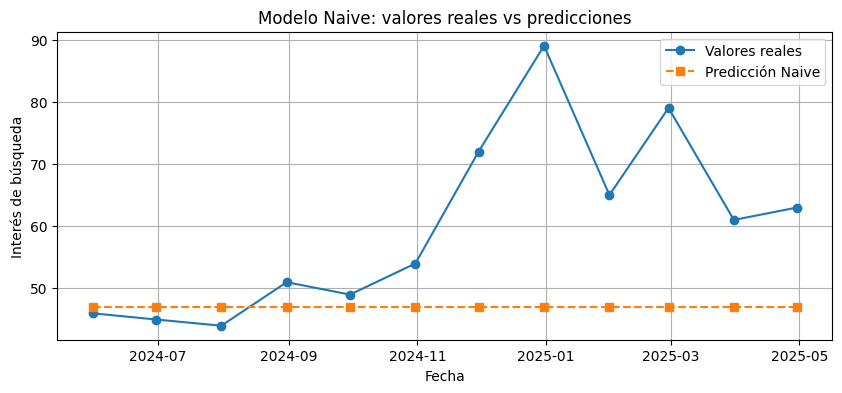

In [14]:
# Ejercicio 2d:

plt.figure(figsize=(10,4))

plt.plot(
    valR.index,
    valR['y'],
    marker='o',
    label='Valores reales'
)

plt.plot(
    valR.index,
    naive_pred,
    marker='s',
    linestyle='--',
    label='Predicción Naive'
)

plt.title('Modelo Naive: valores reales vs predicciones')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda')
plt.legend()
plt.grid(True)

plt.show()


# **C - modelo ARIMA**

# **Ejercicio - 3**

* **3a. Aplica el modelo ARIMA con los conjuntos de entrenamiento y validación trainR y valR, usando como métrica el error absoluto medio. Llamar al error maeARIMA.**

* **3b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ARIMA, junto con los valores reales.**

In [19]:
# Ejercicio 3a - ARIMA

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

modelo_arima = auto_arima(
    trainR['y'],
    seasonal=True,
    m=12,
    suppress_warnings=True,
    error_action='ignore'
)


pred_arima = modelo_arima.predict(
    n_periods=len(valR)
)

# Error MAE
maeARIMA = mean_absolute_error(
    valR['y'],
    pred_arima
)


In [20]:
print('\nError-modelo-ARIMA : MAE: %.3f' % maeARIMA)


Error-modelo-ARIMA : MAE: 8.836


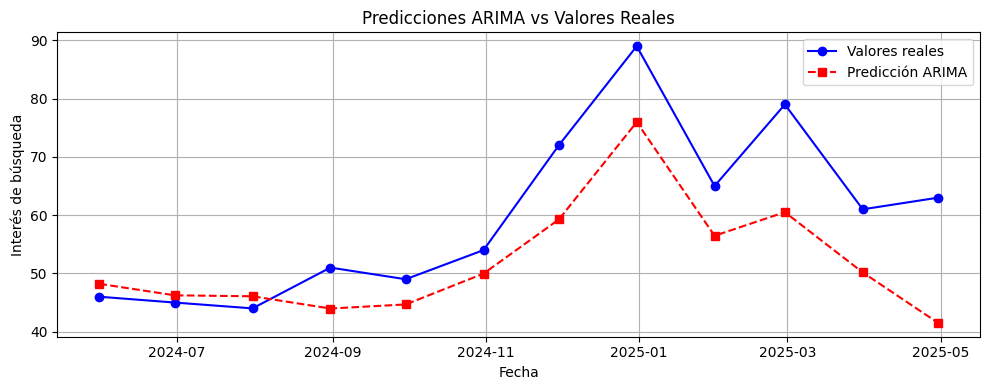

In [21]:
# Ejercicio 3b. ARIMA-gráfica:


plt.figure(figsize=(10,4))

plt.plot(
    valR.index,
    valR['y'],
    color='blue',
    marker='o',
    label='Valores reales'
)

plt.plot(
    valR.index,
    pred_arima,
    color='red',
    marker='s',
    linestyle='--',
    label='Predicción ARIMA'
)

plt.title('Predicciones ARIMA vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **D - modelo Prophet**

# **Ejercicio - 4**

* **4a. Aplica el modelo Prophet con los conjuntos de entrenamiento y validación trainP y valP, usando como métrica el error absoluto medio. Llamar al error maeProphet.**

* **4b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo Prophet-Facebook, junto con los valores reales.**

NOTA: Recuerda siempre iniciar con un modelo sencillo y de ahí buscar la mejor configuración.

In [28]:
# Ejercicio 4a - Prophet

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++


modelo_prophet = Prophet()

modelo_prophet.fit(trainP)


future = modelo_prophet.make_future_dataframe(
    periods=len(valP),
    freq='ME'
)

forecast = modelo_prophet.predict(future)


pred_prophet = forecast['yhat'].tail(len(valP)).values

# Error MAE
maeProphet = mean_absolute_error(
    valP['y'],
    pred_prophet
)


18:59:52 - cmdstanpy - INFO - Chain [1] start processing
18:59:52 - cmdstanpy - INFO - Chain [1] done processing


In [29]:
print('\nError-modelo-Prophet-Facebook : MAE: %.3f' % maeProphet)


Error-modelo-Prophet-Facebook : MAE: 6.558


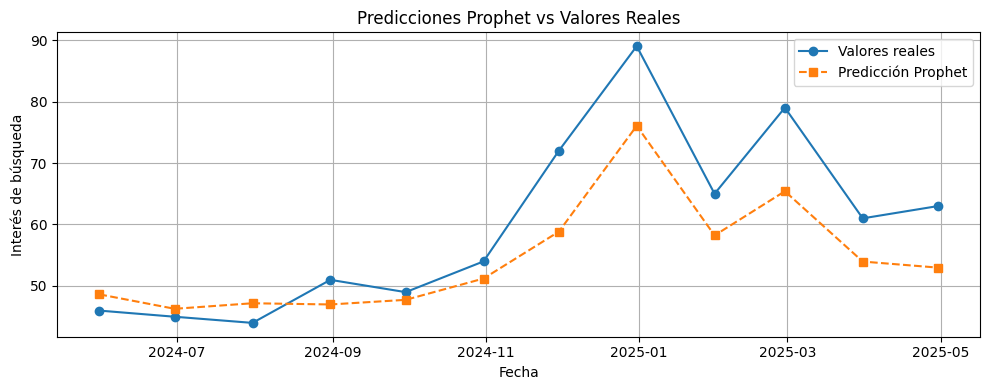

In [30]:
# Ejercicio 4b. Prophet-gráfica:

# ************* Inlcuye aquí tu código:*****************************

plt.figure(figsize=(10,4))

plt.plot(
    valP['ds'],
    valP['y'],
    marker='o',
    label='Valores reales'
)

plt.plot(
    valP['ds'],
    pred_prophet,
    marker='s',
    linestyle='--',
    label='Predicción Prophet'
)

plt.title('Predicciones Prophet vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# *********** Aquí termina la sección de agregar código *************

# **E - modelo LSTM (Deep Learning)**

# **Ejercicio - 5**

* **5a. Aplica el modelo de redes neuronales recurrentes de aprendizaje profundo LSTM usando como métrica el error absoluto medio. Llamar al error maeLSTM. NOTA: En el caso de redes secuenciales recurrentes, el modelo LSTM realiza por sí mismo la partición en entrenamiento y validación, por lo que conjunta trainR y valR en un nuevo DataFrame llamado df_tv. Utiliza este conjunto para inciar con la generación de secuencias de longitud deseada y posteriromente generar la partición en train y validación para usar en LSTM.**

* **5b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo LSTM, junto con los valores reales.**



#### **NOTA: En general, recordemos que los modelos basados en redes neuronales son afectados de manera importante cuando la escala de los datos se va incrementando. Por ello, en este caso podría ser conveniente escalar los datos de nuestra variable temporal, por ejemplo entre 0 y 1. Tomarlo en cuenta para que al final puedes realizar las predicciones en las unidades originales.**

In [33]:
# Ejercicio 5a - LSTM

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++


# Unir train y validation
df_tv = pd.concat([trainR, valR])

# Escalamiento
scaler = MinMaxScaler()

serie = scaler.fit_transform(
    df_tv[['y']]
)

# Longitud de secuencia
window = 12

X = []
y = []

for i in range(window, len(serie)):
    X.append(serie[i-window:i])
    y.append(serie[i])

X = np.array(X)
y = np.array(y)

# Separación train/validación
split = len(trainR) - window

X_train = X[:split]
X_val = X[split:]

y_train = y[:split]
y_val = y[split:]

# Modelo LSTM simple
model = Sequential([
    LSTM(50),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mae'
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=0
)

# Predicciones
pred_lstm = model.predict(X_val)

pred_lstm = scaler.inverse_transform(pred_lstm)

real = scaler.inverse_transform(y_val)

maeLSTM = mean_absolute_error(
    real,
    pred_lstm
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


In [34]:
print('\nError-modelo-LSTM : MAE: %.3f' % maeLSTM)


Error-modelo-LSTM : MAE: 7.379


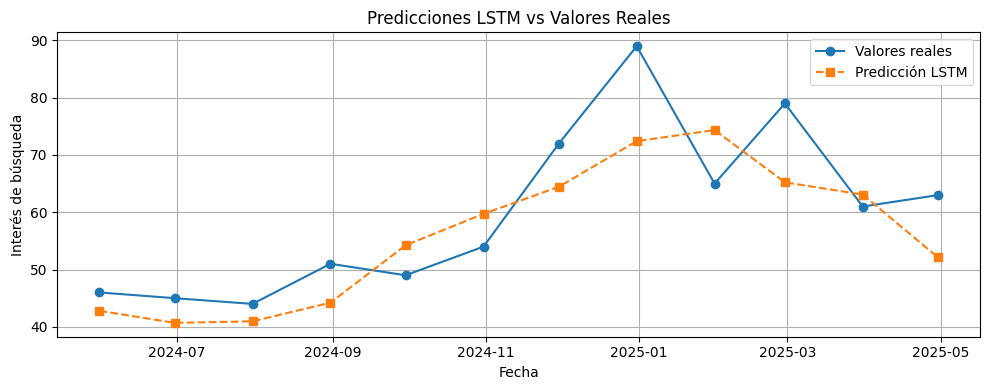

In [35]:
# Ejercicio 5b. LSTM-gráfica:

# ************* Inlcuye aquí tu código:*****************************

plt.figure(figsize=(10,4))

plt.plot(
    valR.index,
    real.flatten(),
    marker='o',
    label='Valores reales'
)

plt.plot(
    valR.index,
    pred_lstm.flatten(),
    marker='s',
    linestyle='--',
    label='Predicción LSTM'
)

plt.title('Predicciones LSTM vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Interés de búsqueda')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# *********** Aquí termina la sección de agregar código *************

# **F - Conjunto de Prueba y Conclusiones Finales**

# **Ejercicio - 6**

* **Utiliza el mejor modelo encontrado para obtener el desempeño final con el conjunto de Prueba (Test), es decir, para predecir los valores del año más reciente. Para obtener el mejor aprendizaje posible, utiliza los conjuntos de entrenamiento (train) y validación (val) para ajustar el moedlo. Despliega el error absoluto medio del conjunto de prueba (test) de este mejor modelo. Llamarlo maeMejor.**

In [37]:
# Ejercicio 6 - mejor modelo

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

# Unir entrenamiento y validación
train_val = pd.concat([trainP, valP])

# Entrenar nuevamente Prophet
modelo_final = Prophet()

modelo_final.fit(train_val)

# Generar horizonte para el conjunto de prueba
future = modelo_final.make_future_dataframe(
    periods=len(testP),
    freq='ME'
)

forecast = modelo_final.predict(future)

# Predicciones correspondientes al test
pred_test = forecast['yhat'].tail(len(testP)).values

# MAE final
maeMejor = mean_absolute_error(
    testP['y'],
    pred_test
)


19:06:55 - cmdstanpy - INFO - Chain [1] start processing
19:06:55 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
print('\nError-del-mejor-modelo-Test : MAE: %.3f' % maeMejor)


Error-del-mejor-modelo-Test : MAE: 4.133


### Comparación de desempeño de los modelos

A continuación se presenta una comparación del error absoluto medio (MAE) obtenido por los diferentes modelos evaluados para el pronóstico de la serie temporal de búsquedas de "chocolate" en Google Trends. Se incluyen el modelo Naive, ARIMA, LSTM y Prophet. Un menor valor de MAE indica una mayor precisión en las predicciones. Además, se muestra el desempeño final del mejor modelo (Prophet) evaluado sobre el conjunto de prueba.

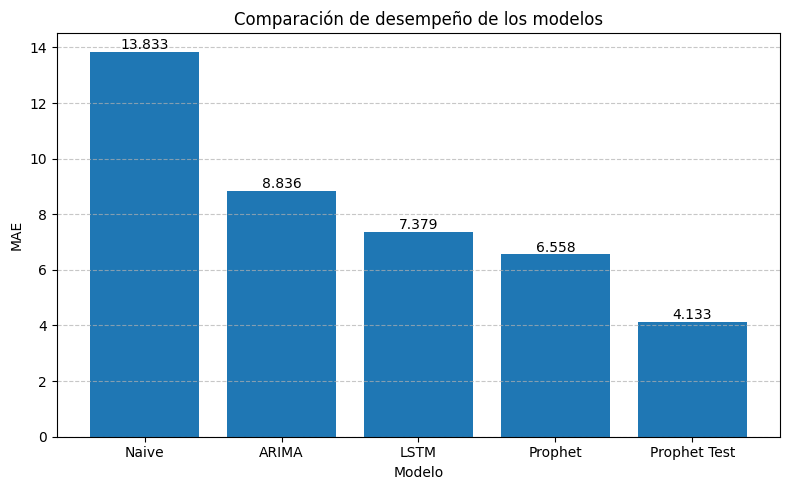

In [41]:
import matplotlib.pyplot as plt

modelos = ['Naive', 'ARIMA', 'LSTM', 'Prophet', 'Prophet Test']
maes = [13.833, 8.836, 7.379, 6.558, 4.133]

plt.figure(figsize=(8,5))

bars = plt.bar(modelos, maes)

plt.title('Comparación de desempeño de los modelos')
plt.ylabel('MAE')
plt.xlabel('Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valor encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.1,
        f'{yval:.3f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

# **Ejercicio - 7**

* **Incluye tus comentarios y conclusiones finales de la actividad.**


## Comentarios y conclusiones finales

En esta actividad se analizaron distintas técnicas de pronóstico de series de tiempo utilizando datos históricos de Google Trends correspondientes a las búsquedas del término **"chocolate"** en Estados Unidos. Se compararon enfoques clásicos y modernos, incluyendo un modelo ingenuo (Naive), un modelo estadístico ARIMA, un modelo basado en descomposición de tendencias y estacionalidad (Prophet) y una red neuronal recurrente LSTM de aprendizaje profundo.

Los resultados obtenidos mostraron diferencias importantes en la capacidad predictiva de cada modelo. El modelo Naive presentó el mayor error (MAE = 13.833), ya que únicamente utiliza el último valor observado como pronóstico y no considera patrones temporales. ARIMA logró una mejora significativa alcanzando un MAE de 8.836 al modelar la dependencia temporal y la estacionalidad de la serie. Por su parte, el modelo LSTM obtuvo un MAE de 7.379, demostrando que las técnicas de aprendizaje profundo pueden capturar relaciones complejas en los datos temporales.

El mejor desempeño fue alcanzado por **Prophet-Facebook**, con un MAE de 6.558 en el conjunto de validación. Posteriormente, al reentrenar el modelo utilizando conjuntamente los datos de entrenamiento y validación, se obtuvo un **MAE de 4.133 en el conjunto de prueba**, confirmando su capacidad para generalizar adecuadamente y generar pronósticos precisos sobre datos no observados.

En conclusión, Prophet resultó ser el modelo más adecuado para esta serie temporal debido a su capacidad para representar tendencias y patrones estacionales de manera eficiente. Asimismo, la actividad permitió comprender las diferencias entre métodos tradicionales y técnicas modernas de aprendizaje automático y aprendizaje profundo aplicadas al problema de pronóstico de series de tiempo.

# **++ Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo ++**